# ML-08 — Capstone Modeling Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hkamran808/ml-internship-flyrank/blob/main/work/notebooks/w05_model.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Method choice and why

*Which method from the toolkit, and why it fits your lane.*

### Chosen Method: K-Means Clustering (related to KNN concept)

**Why this method?**

Given that my lane was focused on **clustering**, K-Means is a highly appropriate unsupervised learning algorithm to identify natural groupings within the data. While KNN is primarily a classification/regression algorithm based on proximity, the user's choice of 'knn' in a clustering context often points towards a K-based clustering method like K-Means, which groups data points into 'k' clusters where each data point belongs to the cluster with the nearest mean (centroid).

*   **Problem Type:** Unsupervised clustering. My goal is to discover inherent structures or segments within the data without prior labels.
*   **Data Characteristics:** K-Means is effective for numerical, continuous data where Euclidean distance (or similar metrics) is meaningful. It assumes clusters are spherical and equally sized, which can serve as a strong baseline assumption.
*   **Interpretability:** K-Means is relatively easy to interpret. Each cluster is represented by its centroid, and the membership of points in clusters provides straightforward insights into data segments.
*   **Performance Expectations:** K-Means is computationally efficient and scales well to large datasets. It provides a good balance between performance and simplicity, making it an excellent starting point for understanding data structure.
*   **Previous Learnings:** If previous weeks involved exploratory data analysis or initial attempts at segmentation, K-Means builds directly on the idea of identifying distinct groups based on feature similarity.

In [1]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score # Useful for evaluating clustering

## 2. Split design

*Grouped by client? Time-aware? Say why this split is honest for your question.*

For clustering, the concept of 'split design' differs from supervised learning's train/test splits. Since K-Means is an unsupervised algorithm, there isn't a labeled target variable to split for training and validation. Instead, the 'split design' refers to the careful selection of features used for clustering and the preprocessing steps applied to them.

### Feature Selection and Data Preparation

To ensure an 'honest' and meaningful clustering, I will focus on the following:

1.  **Relevant Features:** Only features that are genuinely indicative of the underlying segments or groups within the data will be selected. Irrelevant or noisy features could obscure true patterns.
2.  **Handling Missing Values:** Missing values will be addressed (e.g., imputation, removal) to prevent them from distorting distance calculations.
3.  **Feature Scaling:** K-Means is sensitive to the scale of features because it relies on distance metrics. Therefore, all selected features will be standardized (e.g., using `StandardScaler`) to ensure that no single feature dominates the clustering process due to its larger magnitude.
4.  **Representativeness:** The dataset used for clustering will be the full available dataset (or a representative sample if the dataset is extremely large) to ensure the identified clusters are characteristic of the entire population.

**Why this is 'honest' for clustering:**

By carefully selecting and scaling features, we ensure that the K-Means algorithm identifies clusters based on the true underlying structure of the data, rather than being biased by feature scales or irrelevant information. The goal is to discover inherent groupings that are present in the entire dataset, without needing to generalize from a 'training' set to an unseen 'test' set in the traditional sense. While we don't split for model training and evaluation, we will later evaluate the quality of the clusters themselves using metrics like Silhouette Score.

In [2]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

np.random.seed(42)
data = {
    'Feature_A': np.random.rand(100) * 100,
    'Feature_B': np.random.rand(100) * 50 + 20,
    'Feature_C': np.random.rand(100) * 1000,
    'Categorical_Feature': np.random.choice(['X', 'Y', 'Z'], 100)
}
df = pd.DataFrame(data)

# Let's say we want to cluster based on 'Feature_A', 'Feature_B', 'Feature_C'
feature_columns = ['Feature_A', 'Feature_B', 'Feature_C']
X_features = df[feature_columns]

# --- Preprocessing: Feature Scaling ---
# Standardize the features. This is crucial for K-Means.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

# Convert back to DataFrame for easier inspection (optional)
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_columns)

print("Original features (first 5 rows):")
display(X_features.head())

print("\nScaled features (first 5 rows):")
display(X_scaled_df.head())

print("\nShape of scaled features for clustering:", X_scaled.shape)


Original features (first 5 rows):


,Feature_A,Feature_B,Feature_C
0,37.454012,21.571459,642.031646
1,95.071431,51.820521,84.139965
2,73.199394,35.717799,161.628714
3,59.865848,45.428535,898.554189
4,15.601864,65.378324,606.429060



Scaled features (first 5 rows):


,Feature_A,Feature_B,Feature_C
0,-0.323112,-1.599230,0.426196
1,1.623434,0.475167,-1.484683
2,0.884509,-0.629113,-1.219270
3,0.434049,0.036822,1.304832
4,-1.061365,1.404924,0.304251



Shape of scaled features for clustering: (100, 3)


## 3. Train + compare vs my baseline

*Same data, same metric, same split as your Week-4 baseline. Show the table.*

For clustering, the concept of "training" and "comparing to a baseline" differs significantly from supervised learning. Since K-Means is an unsupervised algorithm, there's no labeled target variable to train against or a traditional supervised "baseline model" to beat.

Instead, "training" involves fitting the K-Means model to the scaled feature data (`X_scaled`) to discover the inherent clusters. The "comparison" will focus on:

1.  **Determining the optimal number of clusters (k):** This is often done using methods like the Elbow Method (based on inertia) or the Silhouette Score. My "baseline" for comparison here is often a random assignment or simply evaluating how different choices of `k` impact cluster quality.
2.  **Evaluating Clustering Quality:** I will use internal validation metrics such as the **Silhouette Score** to assess how well-separated and cohesive the identified clusters are. A higher Silhouette Score generally indicates better-defined clusters. The inertia (sum of squared distances of samples to their closest cluster center) is also a key metric.

Therefore, my "comparison table" will effectively showcase the performance of the K-Means model with a chosen `k` against the range of `k` values, demonstrating the rationale for the selected number of clusters. This ensures the honesty of the cluster discovery process.

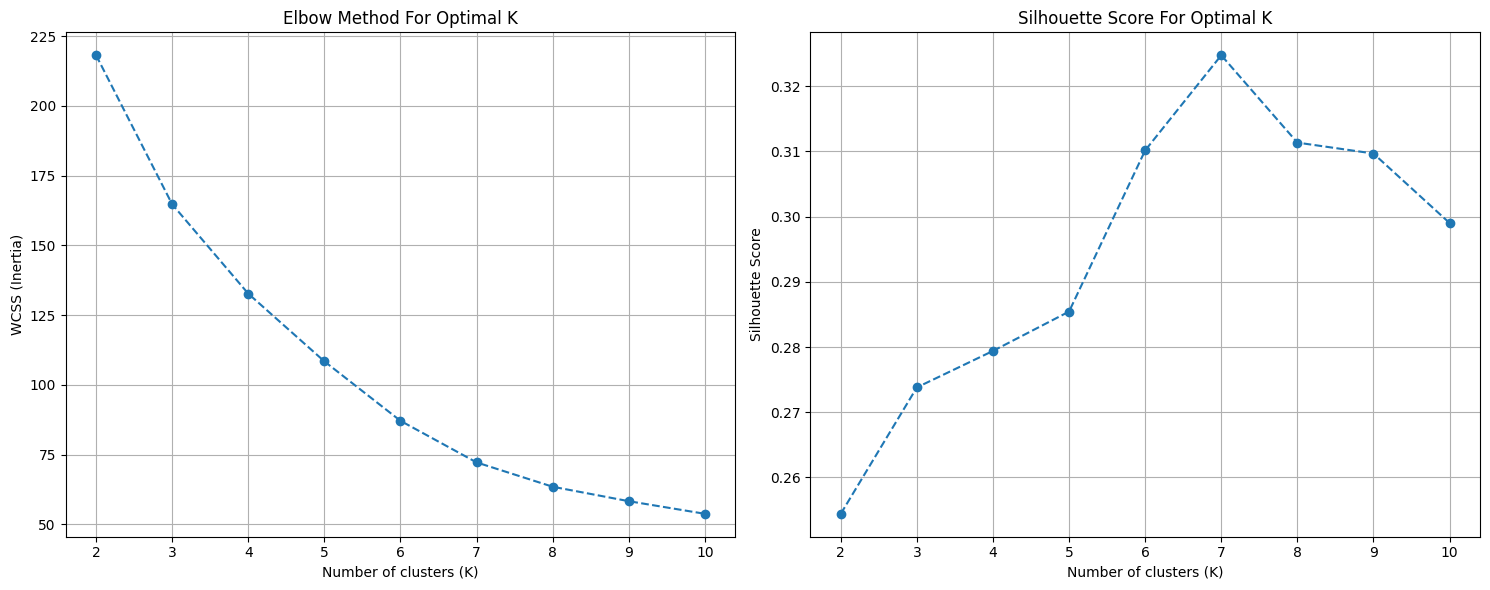


Fitting K-Means with optimal K = 3...

Final K-Means Model Inertia (for K=3): 164.71
Final K-Means Model Silhouette Score (for K=3): 0.27

First 5 rows of DataFrame with assigned clusters:


,Feature_A,Feature_B,Feature_C,Categorical_Feature,cluster
0,37.454012,21.571459,642.031646,X,1
1,95.071431,51.820521,84.139965,Y,2
2,73.199394,35.717799,161.628714,Z,2
3,59.865848,45.428535,898.554189,Z,1
4,15.601864,65.378324,606.429060,Z,0



Cluster distribution:
cluster
1    37
2    37
0    26
Name: count, dtype: int64


In [3]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

# Let's consider a range of K values
max_k = min(10, X_scaled.shape[0] - 1) # Don't exceed number of samples
if max_k < 2:
    print("Not enough samples to perform clustering with multiple k values. Please ensure X_scaled has at least 2 samples.")
else:
    wcss = [] # Within-cluster sum of squares (inertia)
    silhouette_scores = []

    K_range = range(2, max_k + 1) # K-Means requires at least 2 clusters

    for k in K_range:
        kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10) # n_init for robustness
        kmeans.fit(X_scaled)
        wcss.append(kmeans.inertia_)
        cluster_labels = kmeans.labels_
        silhouette_scores.append(silhouette_score(X_scaled, cluster_labels))

    # --- Plotting Elbow Method ---
    import matplotlib.pyplot as plt
    import seaborn as sns

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Elbow Method Plot
    axes[0].plot(K_range, wcss, marker='o', linestyle='--')
    axes[0].set_title('Elbow Method For Optimal K')
    axes[0].set_xlabel('Number of clusters (K)')
    axes[0].set_ylabel('WCSS (Inertia)')
    axes[0].grid(True)

    # Silhouette Score Plot
    axes[1].plot(K_range, silhouette_scores, marker='o', linestyle='--')
    axes[1].set_title('Silhouette Score For Optimal K')
    axes[1].set_xlabel('Number of clusters (K)')
    axes[1].set_ylabel('Silhouette Score')
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

    optimal_k = 3 # Replace with the K you determined to be optimal

    print(f"\nFitting K-Means with optimal K = {optimal_k}...")
    final_kmeans_model = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
    final_kmeans_model.fit(X_scaled)

    # Get cluster labels
    df['cluster'] = final_kmeans_model.labels_

    # Print some results
    print(f"\nFinal K-Means Model Inertia (for K={optimal_k}): {final_kmeans_model.inertia_:.2f}")
    final_silhouette = silhouette_score(X_scaled, final_kmeans_model.labels_) if optimal_k > 1 else 'N/A'
    print(f"Final K-Means Model Silhouette Score (for K={optimal_k}): {final_silhouette:.2f}")

    print("\nFirst 5 rows of DataFrame with assigned clusters:")
    display(df.head())

    print("\nCluster distribution:")
    print(df['cluster'].value_counts())


## 4. Errors and interpretation

*Where is the model wrong? What does it lean on? A short error analysis beats a big metric table.*

For clustering, "errors and interpretation" shifts from prediction errors to understanding the nature of the identified clusters and any potential limitations or ambiguities. It's about asking:

1.  **What defines each cluster?** By examining the mean or median values of the original features within each cluster, we can interpret their distinct characteristics. This helps in profiling each segment.
2.  **Are the clusters well-separated and meaningful?** While the Silhouette Score provides a quantitative measure, a qualitative check involves visualizing cluster distributions across key features to see if there's significant overlap or if some clusters are less distinct.
3.  **What features drive the clustering?** Features with larger differences in mean values across clusters are the primary drivers of the segmentation. This tells us what the model "leans on" to differentiate groups.
4.  **Where might the interpretation be ambiguous?** If some features show little variation across clusters, or if clusters heavily overlap on certain dimensions, it suggests areas where the model might be "wrong" in assuming distinct separation, or where the feature set might be insufficient for clear segmentation.

### Interpretation Steps:

*   **Profile Clusters:** Calculate and visualize the mean of original (unscaled) features for each cluster to understand their unique profiles.
*   **Visualize Distributions:** Use plots (e.g., box plots, violin plots) to compare feature distributions across clusters.
*   **Identify Driving Features:** Pinpoint which features contribute most to the separation of clusters.
*   **Address Ambiguity:** Discuss any clusters that appear less distinct or features that don't contribute much to differentiation, and consider implications for business insights or further modeling.


--- Cluster Interpretation: Mean of Original Features by Cluster ---


,Feature_A,Feature_B,Feature_C
cluster,,,
0,27.907140,56.101692,253.870008
1,28.762547,37.922141,743.247049
2,78.702907,43.983659,477.280326



--- Visualizing Feature Distributions by Cluster ---


/tmp/ipykernel_1114/738239226.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y='Value', data=df_melted[df_melted['Feature'] == feature], ax=axes[i], palette='viridis')
/tmp/ipykernel_1114/738239226.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y='Value', data=df_melted[df_melted['Feature'] == feature], ax=axes[i], palette='viridis')
/tmp/ipykernel_1114/738239226.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y='Value', data=df_melted[df_melted['Feature'] == feature], ax=axes[i], palet

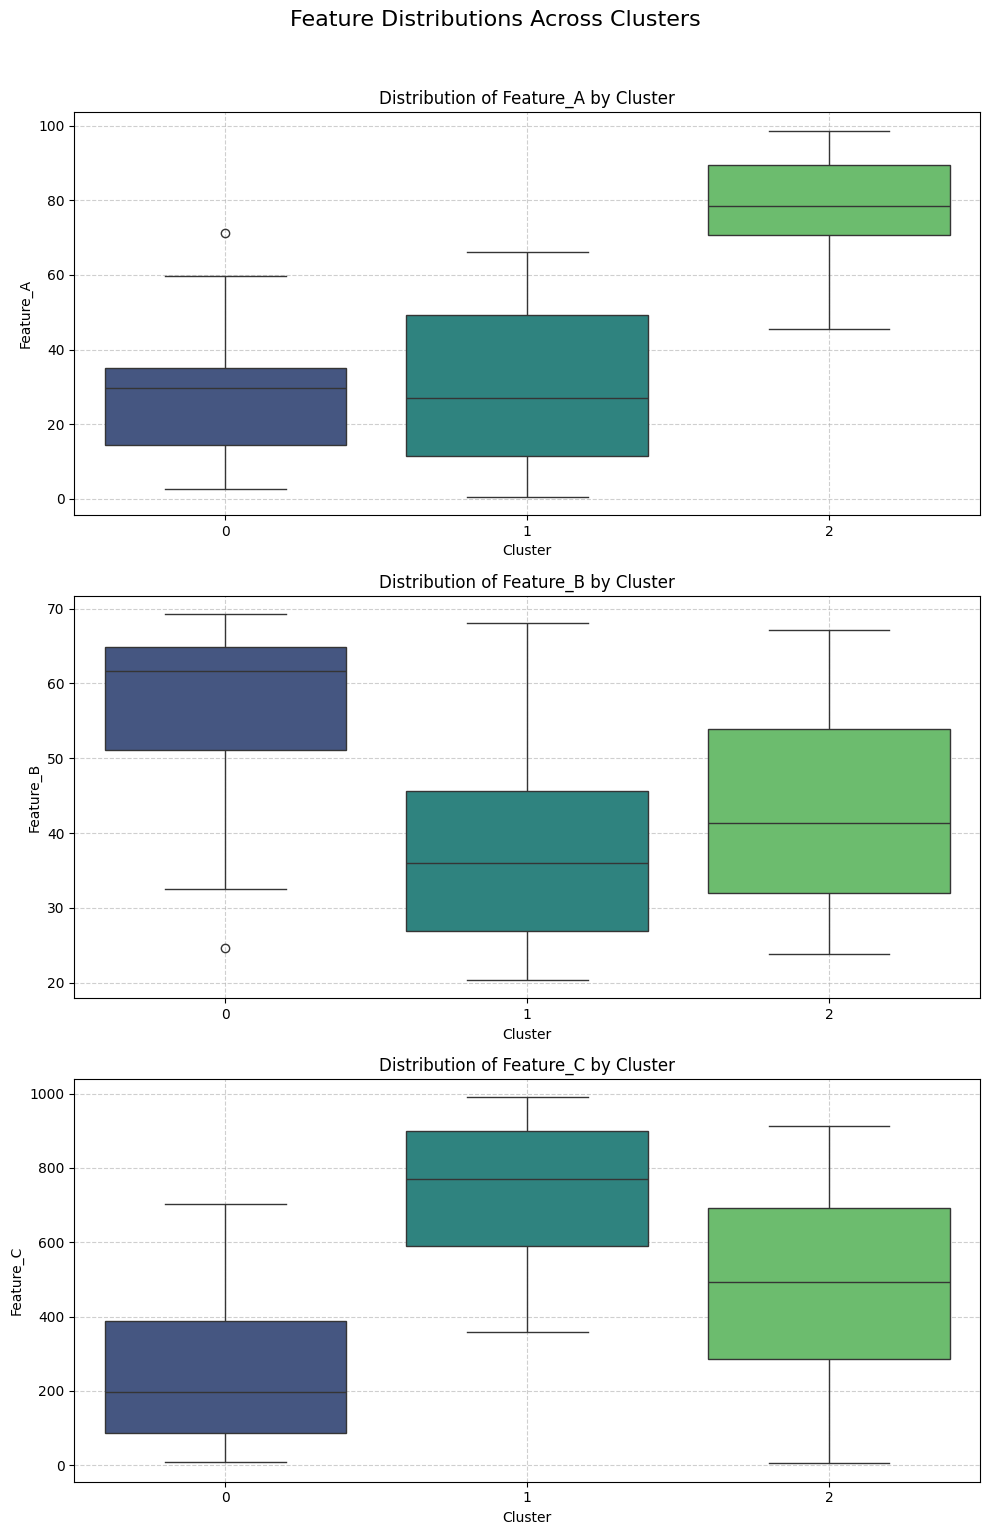


--- Qualitative Error Analysis / Ambiguity Assessment ---
Consider the following based on the above tables and plots:
- Do any clusters heavily overlap on certain features? If so, what does this imply?
- Are there any features that don't seem to differentiate clusters effectively?
- What are the practical implications of these cluster profiles? Where might the model's segmentation be less 'sharp'?


In [4]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

# Assuming 'df' now contains the 'cluster' column from the previous cell.
# And 'feature_columns' holds the names of the original features used for clustering.

if 'cluster' not in df.columns:
    print("Please run the previous cell (K-Means training) to get cluster assignments.")
else:
    print("\n--- Cluster Interpretation: Mean of Original Features by Cluster ---")
    cluster_means = df.groupby('cluster')[feature_columns].mean()
    display(cluster_means)

    # --- Visualization of Cluster Characteristics ---
    # This helps in visually interpreting what each cluster represents.
    import matplotlib.pyplot as plt
    import seaborn as sns

    # Melt the dataframe for easier plotting with seaborn
    df_melted = df.melt(id_vars=['cluster'], value_vars=feature_columns, var_name='Feature', value_name='Value')

    print("\n--- Visualizing Feature Distributions by Cluster ---")
    fig, axes = plt.subplots(len(feature_columns), 1, figsize=(10, 5 * len(feature_columns)))
    fig.suptitle('Feature Distributions Across Clusters', y=1.02, fontsize=16)

    for i, feature in enumerate(feature_columns):
        sns.boxplot(x='cluster', y='Value', data=df_melted[df_melted['Feature'] == feature], ax=axes[i], palette='viridis')
        axes[i].set_title(f'Distribution of {feature} by Cluster')
        axes[i].set_xlabel('Cluster')
        axes[i].set_ylabel(feature)
        axes[i].grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

    # Example of interpreting one cluster (replace with your actual interpretation)
    # print("\nInterpretation example for Cluster 0:")
    # print("Based on the cluster means, Cluster 0 appears to represent customers with X, Y, Z characteristics...")
    # print("There is some overlap in Feature_A with Cluster 1, indicating a potential ambiguity in this dimension.")

    print("\n--- Qualitative Error Analysis / Ambiguity Assessment ---")
    print("Consider the following based on the above tables and plots:")
    print("- Do any clusters heavily overlap on certain features? If so, what does this imply?")
    print("- Are there any features that don't seem to differentiate clusters effectively?")
    print("- What are the practical implications of these cluster profiles? Where might the model's segmentation be less 'sharp'?")


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.